In [20]:
import os
import random
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

In [21]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [22]:
DATASET_ROOT = Path(r"C:\Users\12162\Documents\cats_vs_dogs_small")
IMG_SIZE = (150, 150)
BATCH_SIZE = 20

SCRATCH_SAMPLE_SIZES = [1000, 1500, 2000]
PRETRAINED_SAMPLE_SIZES = [1000, 1500, 2000]

VALIDATION_SIZE = 500
TEST_SIZE = 500


In [23]:
def count_images_in_class(folder):
    if not folder.exists():
        return 0
    return len([f for f in folder.iterdir() if f.is_file()])

def verify_dataset_structure(root):
    required = [
        root / "train" / "cats",
        root / "train" / "dogs",
        root / "validation" / "cats",
        root / "validation" / "dogs",
        root / "test" / "cats",
        root / "test" / "dogs",
    ]
    for p in required:
        if not p.exists():
            raise FileNotFoundError(f"Missing folder: {p}")

def show_dataset_counts(root):
    for split in ["train", "validation", "test"]:
        cats = count_images_in_class(root / split / "cats")
        dogs = count_images_in_class(root / split / "dogs")
        print(f"{split:10s} -> cats: {cats:4d}, dogs: {dogs:4d}, total: {cats + dogs:4d}")

def prepare_sampled_dataset(
    source_root,
    output_root,
    train_total=1000,
    val_total=500,
    test_total=500,
    seed=42
):
    random.seed(seed)

    if output_root.exists():
        shutil.rmtree(output_root)

    for split in ["train", "validation", "test"]:
        for cls in ["cats", "dogs"]:
            (output_root / split / cls).mkdir(parents=True, exist_ok=True)

    split_sizes = {
        "train": train_total // 2,
        "validation": val_total // 2,
        "test": test_total // 2,
    }

    for split in ["train", "validation", "test"]:
        for cls in ["cats", "dogs"]:
            src_dir = source_root / split / cls
            dst_dir = output_root / split / cls

            files = [f for f in src_dir.iterdir() if f.is_file()]
            random.shuffle(files)

            n_needed = split_sizes[split]
            if len(files) < n_needed:
                raise ValueError(
                    f"Not enough images in {src_dir}. Need {n_needed}, found {len(files)}."
                )

            for f in files[:n_needed]:
                shutil.copy2(f, dst_dir / f.name)

def make_datasets(root, img_size=(180, 180), batch_size=32):
    train_ds = keras.utils.image_dataset_from_directory(
        root / "train",
        image_size=img_size,
        batch_size=batch_size,
        label_mode="binary",
        shuffle=True,
        seed=SEED
    )

    val_ds = keras.utils.image_dataset_from_directory(
        root / "validation",
        image_size=img_size,
        batch_size=batch_size,
        label_mode="binary",
        shuffle=False
    )

    test_ds = keras.utils.image_dataset_from_directory(
        root / "test",
        image_size=img_size,
        batch_size=batch_size,
        label_mode="binary",
        shuffle=False
    )

    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)
    test_ds = test_ds.prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds

def plot_history(history, title="Training History"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [24]:
#Model 1: Training from scratch
def build_scratch_model(input_shape=(180, 180, 3)):
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])

    model = keras.Sequential([
        keras.Input(shape=input_shape),

        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model




In [25]:
#Model 2: Pretrained network
def build_pretrained_model(input_shape=(180, 180, 3), train_base=False):
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])

    base_model = keras.applications.Xception(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = train_base

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = keras.applications.xception.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

def fine_tune_pretrained_model(model, base_model, unfreeze_from=-20, lr=1e-5):
    base_model.trainable = True

    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [26]:
#Training functions
def train_and_evaluate_scratch(sample_root, epochs=8, verbose=1):
    train_ds, val_ds, test_ds = make_datasets(sample_root, IMG_SIZE, BATCH_SIZE)
    model = build_scratch_model(input_shape=IMG_SIZE + (3,))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=verbose
    )

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    return model, history, test_loss, test_acc

def train_and_evaluate_pretrained(sample_root, warmup_epochs=3, finetune_epochs=2, verbose=1):
    train_ds, val_ds, test_ds = make_datasets(sample_root, IMG_SIZE, BATCH_SIZE)

    model, base_model = build_pretrained_model(input_shape=IMG_SIZE + (3,), train_base=False)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=4, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
        )
    ]

    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=warmup_epochs,
        callbacks=callbacks,
        verbose=verbose
    )

    if "fine_tune_pretrained_model" in globals():
        model = fine_tune_pretrained_model(model, base_model, unfreeze_from=-20, lr=1e-5)
    else:
        base_model.trainable = True
        for layer in base_model.layers[:-20]:
            layer.trainable = False

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-5),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=finetune_epochs,
        callbacks=callbacks,
        verbose=verbose
    )

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    merged_history = {}
    for key in history1.history:
        merged_history[key] = history1.history[key] + history2.history.get(key, [])

    class HistoryWrapper:
        def __init__(self, history_dict):
            self.history = history_dict

    return model, HistoryWrapper(merged_history), test_loss, test_acc


In [27]:
#Experiment runner
def run_experiment_series(source_root, sample_sizes, mode="scratch"):
    results = []

    for train_size in sample_sizes:
        sample_root = Path(f"sampled_data_{mode}_{train_size}")

        prepare_sampled_dataset(
            source_root=source_root,
            output_root=sample_root,
            train_total=train_size,
            val_total=VALIDATION_SIZE,
            test_total=TEST_SIZE,
            seed=SEED
        )

        print("\n" + "=" * 60)
        print(f"Mode: {mode.upper()} | Training size: {train_size}")
        show_dataset_counts(sample_root)

        if mode == "scratch":
            model, history, test_loss, test_acc = train_and_evaluate_scratch(sample_root)
        else:
            model, history, test_loss, test_acc = train_and_evaluate_pretrained(sample_root)

        plot_history(history, title=f"{mode.capitalize()} - Train Size {train_size}")

        results.append({
            "mode": mode,
            "train_size": train_size,
            "test_loss": round(float(test_loss), 4),
            "test_accuracy": round(float(test_acc), 4)
        })

        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")

    return pd.DataFrame(results)

Original dataset counts:
train      -> cats: 1000, dogs: 1000, total: 2000
validation -> cats:  500, dogs:  500, total: 1000
test       -> cats:  500, dogs:  500, total: 1000

Mode: SCRATCH | Training size: 1000
train      -> cats:  500, dogs:  500, total: 1000
validation -> cats:  250, dogs:  250, total:  500
test       -> cats:  250, dogs:  250, total:  500
Found 1000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 409ms/step - accuracy: 0.4940 - loss: 0.7448 - val_accuracy: 0.5000 - val_loss: 0.7345 - learning_rate: 1.0000e-04
Epoch 2/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 317ms/step - accuracy: 0.5270 - loss: 0.7309 - val_accuracy: 0.5000 - val_loss: 0.7272 - learning_rate: 1.0000e-04
Epoch 3/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 326ms/step - accuracy: 0.5050 - loss: 0.7274 - val_accuracy: 0.5000 - val_loss: 0.7228 - learning_rate: 1.0000e-04
Epoch 4/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 311ms/st

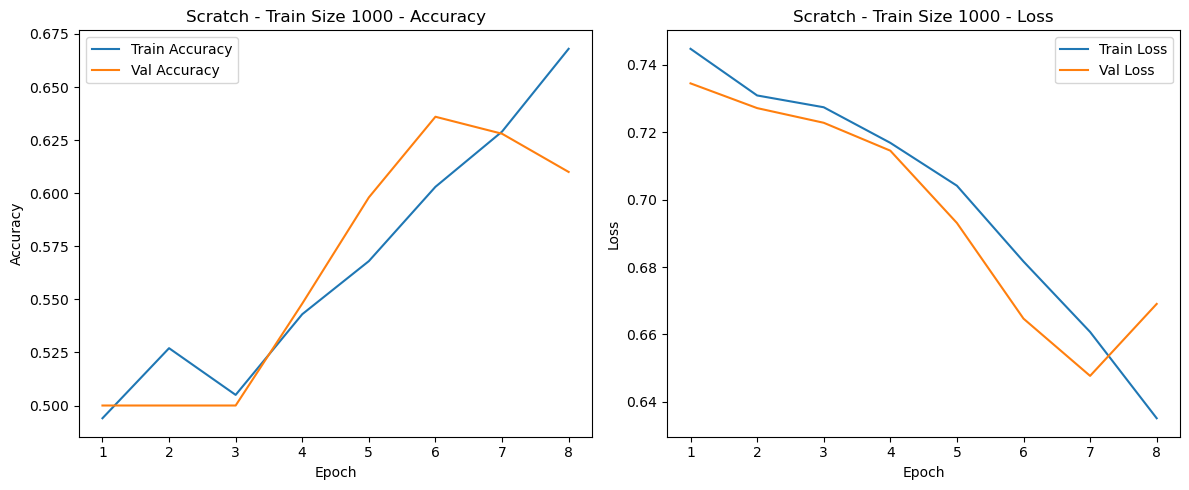

Test Accuracy: 0.6660
Test Loss: 0.6587

Mode: SCRATCH | Training size: 1500
train      -> cats:  750, dogs:  750, total: 1500
validation -> cats:  250, dogs:  250, total:  500
test       -> cats:  250, dogs:  250, total:  500
Found 1500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 26s 279ms/step - accuracy: 0.5073 - loss: 0.7389 - val_accuracy: 0.5000 - val_loss: 0.7295 - learning_rate: 1.0000e-04
Epoch 2/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.5547 - loss: 0.7150 - val_accuracy: 0.5740 - val_loss: 0.7060 - learning_rate: 1.0000e-04
Epoch 3/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.6040 - loss: 0.6955 - val_accuracy: 0.6380 - val_loss: 0.6638 - learning_rate: 1.0000e-04
Epoch 4/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 235ms/step - accuracy: 0.6727 - loss: 0.6523 - val_accuracy: 0.5700 - val_loss: 0.7222 - learning_rate: 1.0000e-04
Epoch 5/8
75/75 ━━━━━━━━━━━━

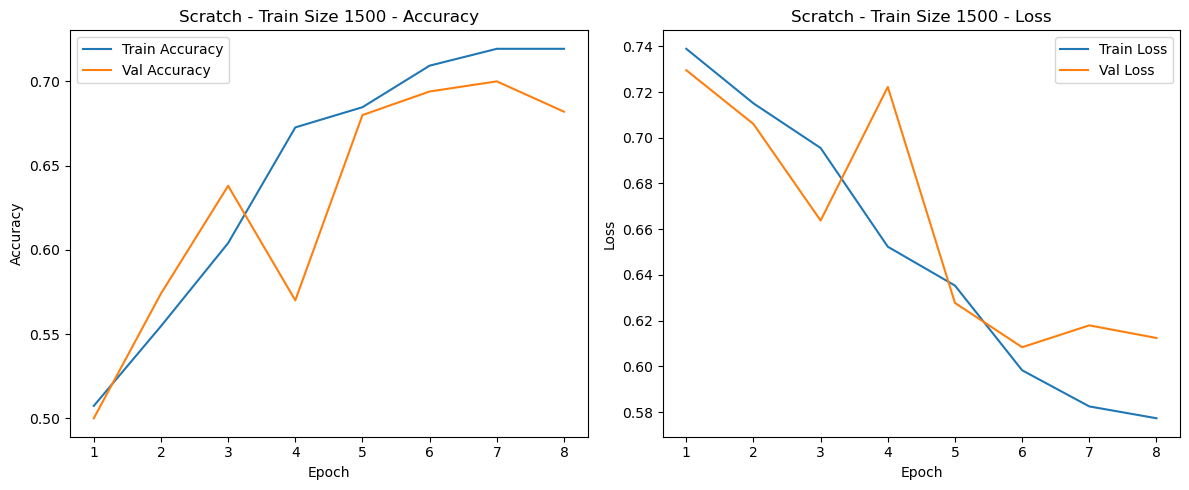

Test Accuracy: 0.7220
Test Loss: 0.6024

Mode: SCRATCH | Training size: 2000
train      -> cats: 1000, dogs: 1000, total: 2000
validation -> cats:  250, dogs:  250, total:  500
test       -> cats:  250, dogs:  250, total:  500
Found 2000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 266ms/step - accuracy: 0.5390 - loss: 0.7341 - val_accuracy: 0.5140 - val_loss: 0.7223 - learning_rate: 1.0000e-04
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 246ms/step - accuracy: 0.5755 - loss: 0.7107 - val_accuracy: 0.5980 - val_loss: 0.6867 - learning_rate: 1.0000e-04
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 251ms/step - accuracy: 0.6555 - loss: 0.6551 - val_accuracy: 0.6540 - val_loss: 0.6398 - learning_rate: 1.0000e-04
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 272ms/step - accuracy: 0.6910 - loss: 0.6268 - val_accuracy: 0.6380 - val_loss: 0.6542 - learning_rate: 1.0000e-04
Epoch 5/8
100/100 ━━

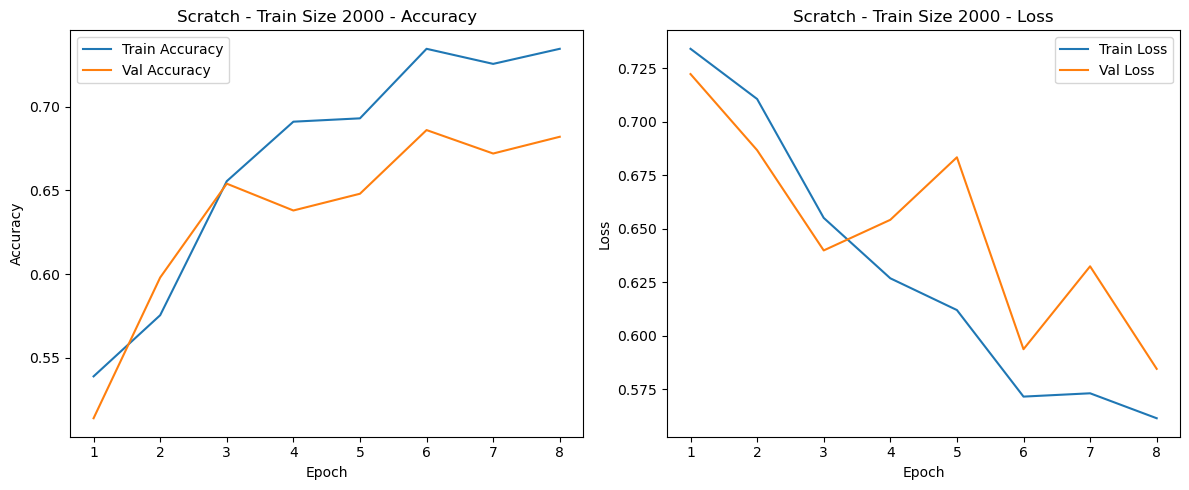

Test Accuracy: 0.7160
Test Loss: 0.5936

Mode: PRETRAINED | Training size: 1000
train      -> cats:  500, dogs:  500, total: 1000
validation -> cats:  250, dogs:  250, total:  500
test       -> cats:  250, dogs:  250, total:  500
Found 1000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 774ms/step - accuracy: 0.6340 - loss: 0.6517 - val_accuracy: 0.7880 - val_loss: 0.5258 - learning_rate: 1.0000e-04
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 676ms/step - accuracy: 0.7480 - loss: 0.5200 - val_accuracy: 0.8640 - val_loss: 0.3939 - learning_rate: 1.0000e-04
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 715ms/step - accuracy: 0.8110 - loss: 0.4257 - val_accuracy: 0.9060 - val_loss: 0.3170 - learning_rate: 1.0000e-04
Epoch 1/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 910ms/step - accuracy: 0.8080 - loss: 0.5558 - val_accuracy: 0.9220 - val_loss: 0.2272 - learning_rate: 1.0000e-05
Epoch 2/2
50/50 ━━━━━━━━━

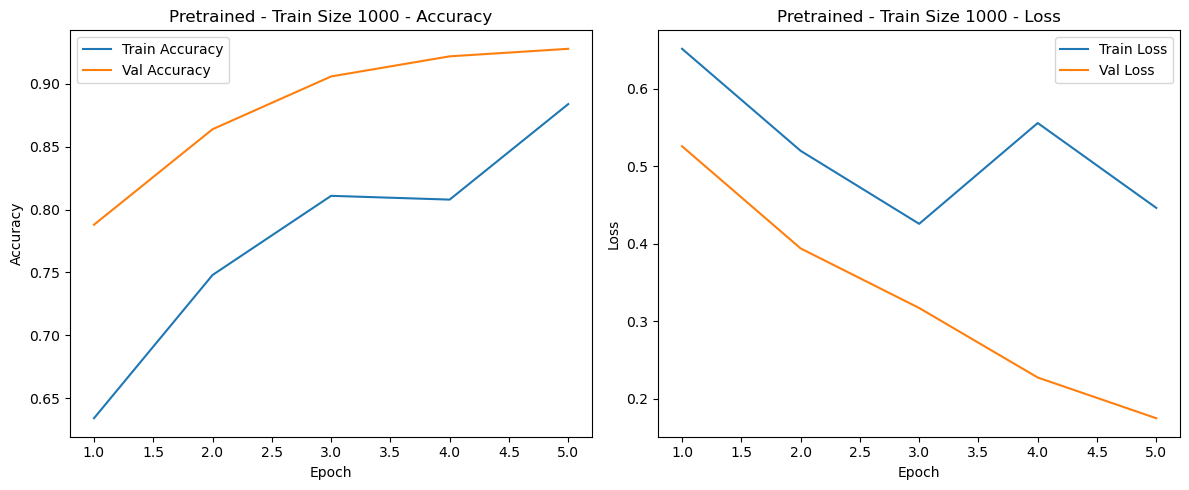

Test Accuracy: 0.9620
Test Loss: 0.1603

Mode: PRETRAINED | Training size: 1500
train      -> cats:  750, dogs:  750, total: 1500
validation -> cats:  250, dogs:  250, total:  500
test       -> cats:  250, dogs:  250, total:  500
Found 1500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 59s 675ms/step - accuracy: 0.6753 - loss: 0.6082 - val_accuracy: 0.8400 - val_loss: 0.4390 - learning_rate: 1.0000e-04
Epoch 2/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 603ms/step - accuracy: 0.8213 - loss: 0.4207 - val_accuracy: 0.9040 - val_loss: 0.3111 - learning_rate: 1.0000e-04
Epoch 3/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 41s 545ms/step - accuracy: 0.8813 - loss: 0.3324 - val_accuracy: 0.9240 - val_loss: 0.2467 - learning_rate: 1.0000e-04
Epoch 1/2
75/75 ━━━━━━━━━━━━━━━━━━━━ 68s 797ms/step - accuracy: 0.8180 - loss: 0.5087 - val_accuracy: 0.9320 - val_loss: 0.1740 - learning_rate: 1.0000e-05
Epoch 2/2
75/75 ━━━━━━━━━

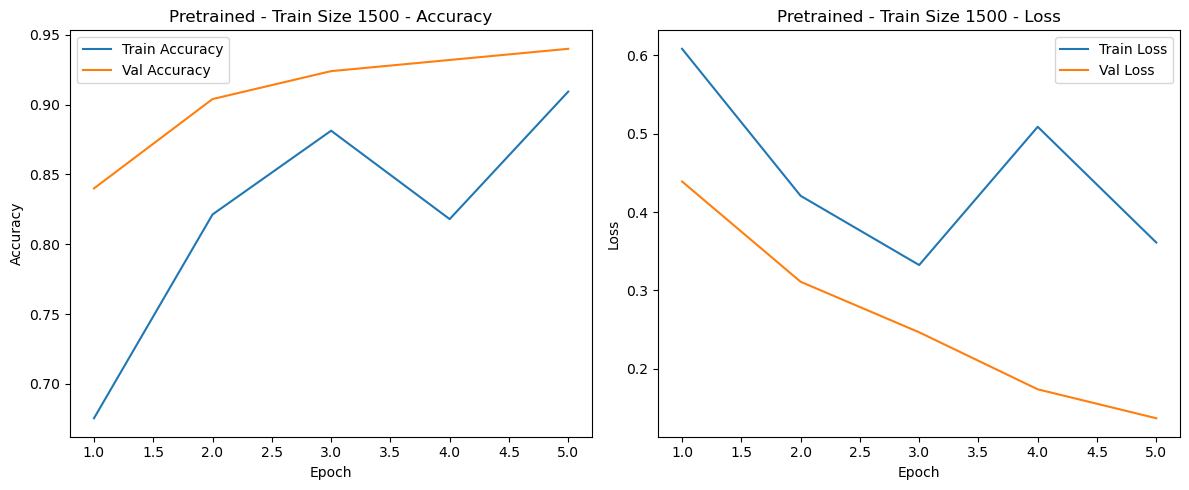

Test Accuracy: 0.9700
Test Loss: 0.1181

Mode: PRETRAINED | Training size: 2000
train      -> cats: 1000, dogs: 1000, total: 2000
validation -> cats:  250, dogs:  250, total:  500
test       -> cats:  250, dogs:  250, total:  500
Found 2000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 702ms/step - accuracy: 0.6985 - loss: 0.5673 - val_accuracy: 0.8680 - val_loss: 0.3836 - learning_rate: 1.0000e-04
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 66s 659ms/step - accuracy: 0.8580 - loss: 0.3716 - val_accuracy: 0.9120 - val_loss: 0.2626 - learning_rate: 1.0000e-04
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 64s 635ms/step - accuracy: 0.8965 - loss: 0.2862 - val_accuracy: 0.9300 - val_loss: 0.2068 - learning_rate: 1.0000e-04
Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 85s 710ms/step - accuracy: 0.8485 - loss: 0.4689 - val_accuracy: 0.9360 - val_loss: 0.1485 - learning_rate: 1.0000e-05
Epoch 2/2
100/100

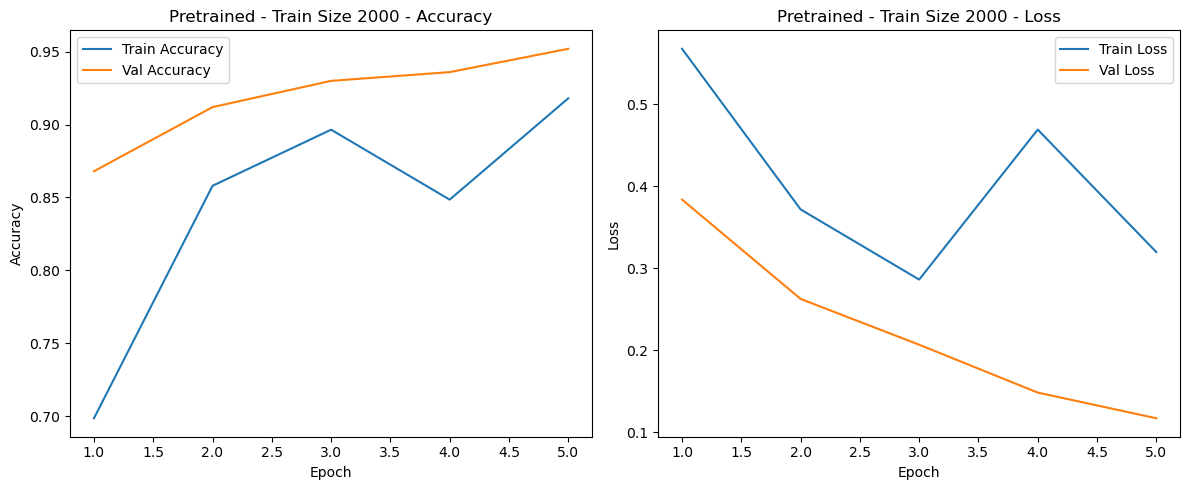

Test Accuracy: 0.9700
Test Loss: 0.1023

SCRATCH RESULTS
      mode  train_size  test_loss  test_accuracy
0  scratch        1000     0.6587          0.666
1  scratch        1500     0.6024          0.722
2  scratch        2000     0.5936          0.716

PRETRAINED RESULTS
         mode  train_size  test_loss  test_accuracy
0  pretrained        1000     0.1603          0.962
1  pretrained        1500     0.1181          0.970
2  pretrained        2000     0.1023          0.970

BEST SCRATCH MODEL
mode             scratch
train_size          1500
test_loss         0.6024
test_accuracy      0.722
Name: 1, dtype: object

BEST PRETRAINED MODEL
mode             pretrained
train_size             1500
test_loss            0.1181
test_accuracy          0.97
Name: 1, dtype: object

Saved results to cats_dogs_assignment_results.csv


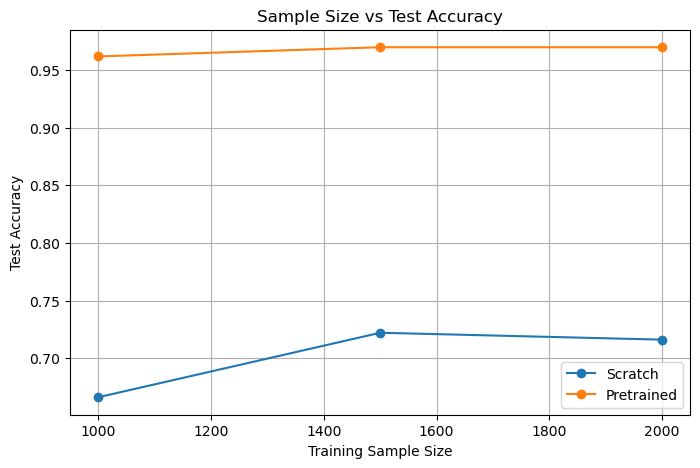

In [28]:
#Main
def main():
    verify_dataset_structure(DATASET_ROOT)

    print("Original dataset counts:")
    show_dataset_counts(DATASET_ROOT)

    # From scratch experiments
    scratch_results = run_experiment_series(
        source_root=DATASET_ROOT,
        sample_sizes=SCRATCH_SAMPLE_SIZES,
        mode="scratch"
    )

    best_scratch = scratch_results.sort_values("test_accuracy", ascending=False).iloc[0]

    # Pretrained experiments
    pretrained_results = run_experiment_series(
        source_root=DATASET_ROOT,
        sample_sizes=PRETRAINED_SAMPLE_SIZES,
        mode="pretrained"
    )

    best_pretrained = pretrained_results.sort_values("test_accuracy", ascending=False).iloc[0]

    print("\n" + "=" * 60)
    print("SCRATCH RESULTS")
    print(scratch_results)

    print("\n" + "=" * 60)
    print("PRETRAINED RESULTS")
    print(pretrained_results)

    print("\n" + "=" * 60)
    print("BEST SCRATCH MODEL")
    print(best_scratch)

    print("\n" + "=" * 60)
    print("BEST PRETRAINED MODEL")
    print(best_pretrained)

    all_results = pd.concat([scratch_results, pretrained_results], ignore_index=True)
    all_results.to_csv("cats_dogs_assignment_results.csv", index=False)
    print("\nSaved results to cats_dogs_assignment_results.csv")

    plt.figure(figsize=(8, 5))

    scratch_df = all_results[all_results["mode"] == "scratch"]
    pretrained_df = all_results[all_results["mode"] == "pretrained"]

    plt.plot(scratch_df["train_size"], scratch_df["test_accuracy"], marker="o", label="Scratch")
    plt.plot(pretrained_df["train_size"], pretrained_df["test_accuracy"], marker="o", label="Pretrained")

    plt.xlabel("Training Sample Size")
    plt.ylabel("Test Accuracy")
    plt.title("Sample Size vs Test Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()